In [1]:
import os as oss
import sys as sys
import time as tme
import json as jsn
import hashlib as hsh
import platform as plf
import urllib.request as req
import importlib.metadata as met
from pathlib import Path as Pth
import numpy as npy
import pandas as pds
import torch as tch
from torch import nn as nnn
from torch.nn import functional as fun
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssm
from IPython.display import display as dsp
tch.set_num_threads(4)
tch.manual_seed(42)
npy.random.seed(42)
tch.use_deterministic_algorithms(True)
dev = tch.device("cpu")
out = Pth("experiment_7_results")
out.mkdir(exist_ok=True)
fig = out / "figures"
fig.mkdir(exist_ok=True)
cfg = {"seed": 42, "train": 10000, "validation": 2000, "test": 2000,
       "epochs": 20, "batch_size": 128, "learning_rate": 0.001,
       "optimizer": "Adam", "device": str(dev), "threads": 4,
       "name": "Joshua", "roll_number": "24110085", "batch": 2,
       "repository": "https://github.com/Joshua-Divide/LAB"}
ver = {nam: met.version(nam) for nam in
       ["torch", "numpy", "pandas", "matplotlib", "scikit-image", "reportlab"]}
cfg["vae_encoder"] = "Conv32 - Conv64 - Flatten - direct mean/log-variance heads"
print(jsn.dumps({"configuration": cfg, "versions": ver}, indent=2))

{
  "configuration": {
    "seed": 42,
    "train": 10000,
    "validation": 2000,
    "test": 2000,
    "epochs": 20,
    "batch_size": 128,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "device": "cpu",
    "threads": 4,
    "name": "Joshua",
    "roll_number": "24110085",
    "batch": 2,
    "repository": "https://github.com/Joshua-Divide/LAB",
    "vae_encoder": "Conv32 - Conv64 - Flatten - direct mean/log-variance heads"
  },
  "versions": {
    "torch": "2.10.0+cpu",
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "matplotlib": "3.10.8",
    "scikit-image": "0.26.0",
    "reportlab": "4.4.9"
  }
}


In [2]:
def fca(dim):
    enc = nnn.Sequential(nnn.Flatten(), nnn.Linear(784, 128), nnn.ReLU(),
                         nnn.Linear(128, 32), nnn.ReLU(),
                         nnn.Linear(32, dim), nnn.ReLU())
    dec = nnn.Sequential(nnn.Linear(dim, 32), nnn.ReLU(),
                         nnn.Linear(32, 128), nnn.ReLU(),
                         nnn.Linear(128, 784), nnn.Unflatten(1, (1, 28, 28)))
    return nnn.ModuleDict({"enc": enc, "dec": dec})
def cae(dim=None, trn=False):
    enc = [nnn.Conv2d(1, 32, 3, padding=1), nnn.ReLU(), nnn.MaxPool2d(2),
           nnn.Conv2d(32, 64, 3, padding=1), nnn.ReLU(), nnn.MaxPool2d(2)]
    dec = []
    if dim is not None:
        enc += [nnn.Flatten(), nnn.Linear(3136, dim)]
        dec += [nnn.Linear(dim, 3136), nnn.ReLU(),
                nnn.Unflatten(1, (64, 7, 7))]
    dec += [nnn.Conv2d(64, 64, 3, padding=1), nnn.ReLU()]
    if trn:
        dec += [nnn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
                nnn.ReLU(), nnn.ConvTranspose2d(32, 1, 4, stride=2, padding=1)]
    else:
        dec += [nnn.Upsample(scale_factor=2, mode="nearest"),
                nnn.Conv2d(64, 32, 3, padding=1), nnn.ReLU(),
                nnn.Upsample(scale_factor=2, mode="nearest"),
                nnn.Conv2d(32, 1, 3, padding=1)]
    return nnn.ModuleDict({"enc": nnn.Sequential(*enc),
                          "dec": nnn.Sequential(*dec)})
def vae(dim):
    enc = nnn.Sequential(nnn.Conv2d(1, 32, 3, stride=2, padding=1), nnn.ReLU(),
                         nnn.Conv2d(32, 64, 3, stride=2, padding=1), nnn.ReLU(),
                         nnn.Flatten())
    dec = nnn.Sequential(nnn.Linear(dim, 3136), nnn.ReLU(),
                         nnn.Unflatten(1, (64, 7, 7)),
                         nnn.ConvTranspose2d(64, 64, 4, stride=2, padding=1),
                         nnn.ReLU(),
                         nnn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
                         nnn.ReLU(), nnn.Conv2d(32, 1, 3, padding=1))
    return nnn.ModuleDict({"enc": enc, "mea": nnn.Linear(3136, dim),
                          "log": nnn.Linear(3136, dim), "dec": dec})
def fwd(mod, inp, smp=False, eps=None):
    lat = mod["enc"](inp)
    kld = tch.zeros(len(inp), device=inp.device)
    if "mea" in mod:
        mea, lvr = mod["mea"](lat), mod["log"](lat)
        kld = -0.5 * (1 + lvr - mea.square() - lvr.exp()).sum(1)
        lat = mea
        if smp:
            eps = tch.randn_like(mea) if eps is None else eps
            lat = mea + tch.exp(0.5 * lvr) * eps
    return mod["dec"](lat), kld, lat
def cnt(mod):
    return sum(par.numel() for par in mod.parameters())
arc = []
for nam, mod in [("FC-AE d=16", fca(16)), ("CAE", cae()),
                 ("Denoising CAE", cae()), ("VAE d=2", vae(2))]:
    with tch.no_grad():
        rec, kld, lat = fwd(mod, tch.zeros(2, 1, 28, 28))
    assert tuple(rec.shape) == (2, 1, 28, 28)
    arc.append({"Model": nam, "Parameters": cnt(mod),
                "Latent shape": str(tuple(lat.shape[1:])),
                "Output shape": str(tuple(rec.shape[1:]))})
dsp(pds.DataFrame(arc))

,Model,Parameters,Latent shape,Output shape
0,FC-AE d=16,211040,"(16,)","(1, 28, 28)"
1,CAE,74497,"(64, 7, 7)","(1, 28, 28)"
2,Denoising CAE,74497,"(64, 7, 7)","(1, 28, 28)"
3,VAE d=2,139461,"(2,)","(1, 28, 28)"


In [3]:
src = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
pth = next((pth for pth in [Pth("mnist.npz"), Pth("data/mnist.npz"),
                           Pth.home() / ".keras/datasets/mnist.npz",
                           Pth("/content/mnist.npz")]
            if pth.is_file()), Pth("mnist.npz"))
if not pth.is_file():
    try:
        with req.urlopen(src, timeout=45) as rsp:
            pth.write_bytes(rsp.read())
    except Exception as err:
        raise RuntimeError("MNIST is unavailable. Place the original mnist.npz "
                           "beside this notebook and run all cells again. "
                           "No substitute data or estimated results are used.") from err
dat = npy.load(pth, allow_pickle=False)
assert dat["x_train"].shape == (60000, 28, 28)
assert dat["x_test"].shape == (10000, 28, 28)
assert dat["y_train"].shape == (60000,)
assert dat["y_test"].shape == (10000,)
rng = npy.random.default_rng(cfg["seed"])
idx = rng.permutation(60000)
tix = rng.permutation(10000)[:cfg["test"]]
xtr = tch.from_numpy(dat["x_train"][idx[:10000]].astype(npy.float32) / 255)[:, None]
xva = tch.from_numpy(dat["x_train"][idx[10000:12000]].astype(npy.float32) / 255)[:, None]
xts = tch.from_numpy(dat["x_test"][tix].astype(npy.float32) / 255)[:, None]
yts = dat["y_test"][tix]
assert not set(idx[:10000]).intersection(idx[10000:12000])
assert len(npy.unique(tix)) == 2000
cfg["dataset_sha256"] = hsh.sha256(pth.read_bytes()).hexdigest()
npy.savez_compressed(out / "split_indices.npz", train=idx[:10000],
                     validation=idx[10000:12000], test=tix)
(out / "configuration.json").write_text(jsn.dumps({"configuration": cfg,
                                                "versions": ver}, indent=2))
print("Training:", tuple(xtr.shape), "Validation:", tuple(xva.shape),
      "Test:", tuple(xts.shape))
print("Range:", float(xtr.min()), float(xtr.max()))
print("Test label counts:", npy.bincount(yts, minlength=10))

Training: (10000, 1, 28, 28) Validation: (2000, 1, 28, 28) Test: (2000, 1, 28, 28)
Range: 0.0 1.0
Test label counts: [197 217 209 213 184 198 185 211 208 178]


In [4]:
def noi(inp, typ, lev, sed):
    gen = tch.Generator().manual_seed(sed)
    if typ == "Gaussian":
        return (inp + lev * tch.randn(inp.shape, generator=gen)).clamp(0, 1)
    if typ == "Salt-pepper":
        rnd = tch.rand(inp.shape, generator=gen)
        return tch.where(rnd < lev / 2, 0,
                         tch.where(rnd > 1 - lev / 2, 1, inp))
    return inp.clone()
def fit(mod, inp, tar, vin, vta, bet=0.0):
    tch.manual_seed(cfg["seed"])
    mod = mod.to(dev).to(memory_format=tch.channels_last)
    opt = tch.optim.Adam(mod.parameters(), lr=cfg["learning_rate"])
    his = []
    beg = tme.perf_counter()
    for epo in range(1, cfg["epochs"] + 1):
        mod.train()
        ord = tch.randperm(len(inp))
        acc = npy.zeros(3, dtype=npy.float64)
        for ids in ord.split(cfg["batch_size"]):
            xxx = inp[ids].to(dev).contiguous(memory_format=tch.channels_last)
            yyy = tar[ids].to(dev)
            opt.zero_grad(set_to_none=True)
            log, kld, lat = fwd(mod, xxx, smp=("mea" in mod))
            rec = fun.binary_cross_entropy_with_logits(log, yyy, reduction="none")
            rec = rec.flatten(1).sum(1) if "mea" in mod else rec.flatten(1).mean(1)
            los = (rec + bet * kld).mean()
            assert tch.isfinite(los)
            los.backward()
            opt.step()
            acc += npy.array([rec.detach().sum().item(),
                              kld.detach().sum().item(),
                              los.detach().item() * len(ids)])
        mod.eval()
        val = npy.zeros(3, dtype=npy.float64)
        gen = tch.Generator().manual_seed(701)
        with tch.no_grad():
            for bix in range(0, len(vin), cfg["batch_size"]):
                ids = slice(bix, bix + cfg["batch_size"])
                xxx = vin[ids].to(dev).contiguous(memory_format=tch.channels_last)
                eps = tch.randn((len(xxx), mod["mea"].out_features), generator=gen) if "mea" in mod else None
                log, kld, lat = fwd(mod, xxx, smp=("mea" in mod), eps=eps)
                rec = fun.binary_cross_entropy_with_logits(log, vta[ids].to(dev), reduction="none")
                rec = rec.flatten(1).sum(1) if "mea" in mod else rec.flatten(1).mean(1)
                val += npy.array([rec.sum().item(), kld.sum().item(),
                                  (rec + bet * kld).sum().item()])
        acc /= len(inp)
        val /= len(vin)
        row = {"epoch": epo, "train_rec": acc[0], "train_kl": acc[1],
               "train_total": acc[2], "val_rec": val[0], "val_kl": val[1],
               "val_total": val[2]}
        his.append(row)
        print(f"Epoch {epo:02d}: train={acc[2]:.6f}, validation={val[2]:.6f}", flush=True)
    return mod, pds.DataFrame(his), tme.perf_counter() - beg
def prd(mod, inp):
    mod.eval()
    arr = []
    with tch.no_grad():
        for bat in inp.split(cfg["batch_size"]):
            log, kld, lat = fwd(mod, bat.to(dev).contiguous(memory_format=tch.channels_last))
            arr.append(tch.sigmoid(log).cpu())
    return tch.cat(arr)
def mts(tar, rec):
    xxx, yyy = tar.numpy()[:, 0], rec.numpy()[:, 0]
    err = npy.square(xxx - yyy).mean(axis=(1, 2))
    mae = npy.abs(xxx - yyy).mean(axis=(1, 2))
    sim = npy.array([ssm(aaa, bbb, data_range=1.0, win_size=7)
                     for aaa, bbb in zip(xxx, yyy)])
    return {"MSE": float(err.mean()), "MAE": float(mae.mean()),
            "SSIM": float(sim.mean())}, err, sim
def obj(mod, inp, bet=1.0):
    mod.eval()
    gen = tch.Generator().manual_seed(801)
    tot = npy.zeros(2, dtype=npy.float64)
    with tch.no_grad():
        for bat in inp.split(cfg["batch_size"]):
            xxx = bat.to(dev).contiguous(memory_format=tch.channels_last)
            eps = tch.randn((len(xxx), mod["mea"].out_features), generator=gen)
            log, kld, lat = fwd(mod, xxx, smp=True, eps=eps)
            rec = fun.binary_cross_entropy_with_logits(log, xxx, reduction="none").flatten(1).sum(1)
            tot += npy.array([rec.sum().item(), kld.sum().item()])
    tot /= len(inp)
    return {"Reconstruction loss": float(tot[0]), "KL loss": float(tot[1]),
            "Total loss": float(tot[0] + bet * tot[1])}
mds, hst, tms, prs, ers, sms, rws = {}, {}, {}, {}, {}, {}, []
def run(nam, mod, typ="Clean", lev=0.0, bet=0.0):
    print("Training", nam, flush=True)
    inp = noi(xtr, typ, lev, 101)
    vin = noi(xva, typ, lev, 201)
    mod, his, sec = fit(mod, inp, xtr, vin, xva, bet)
    rec = prd(mod, noi(xts, typ, lev, 301))
    met, err, sim = mts(xts, rec)
    row = {"Model": nam, "Input": typ, "Level": lev, **met,
           "Parameters": cnt(mod), "Time (s)": sec}
    if "mea" in mod:
        row.update(obj(mod, xts, bet))
    mds[nam], hst[nam], tms[nam], prs[nam] = mod, his, sec, rec
    ers[nam], sms[nam] = err, sim
    rws.append(row)
    his.to_csv(out / (nam + "_history.csv"), index=False)
    tch.save(mod.state_dict(), out / (nam + ".pt"))
    pds.DataFrame(rws).to_csv(out / "results.csv", index=False)
    print(jsn.dumps(row, indent=2), flush=True)

In [5]:
for dim in [2, 8, 16, 32]:
    tch.manual_seed(42)
    run(f"FC_{dim}", fca(dim))

Training FC_2


Epoch 01: train=0.445547, validation=0.277883


Epoch 02: train=0.269027, validation=0.265890


Epoch 03: train=0.264961, validation=0.264558


Epoch 04: train=0.264105, validation=0.263936


...

Epoch 17: train=0.142135, validation=0.142973


Epoch 18: train=0.140716, validation=0.141969


Epoch 19: train=0.139472, validation=0.141487


Epoch 20: train=0.138480, validation=0.139884


{
  "Model": "FC_32",
  "Input": "Clean",
  "Level": 0.0,
  "MSE": 0.025607848539948463,
  "MAE": 0.06678634136915207,
  "SSIM": 0.706837670841888,
  "Parameters": 212080,
  "Time (s)": 4.872761926999999
}


In [6]:
tch.manual_seed(42)
run("CAE", cae())
for dim in [4, 8, 16, 32]:
    tch.manual_seed(42)
    run(f"CAE_{dim}", cae(dim))
tch.manual_seed(42)
run("CAE_transpose", cae(trn=True))

Training CAE


Epoch 01: train=0.260066, validation=0.116772


Epoch 02: train=0.096109, validation=0.086606


Epoch 03: train=0.082441, validation=0.080504


Epoch 04: train=0.078210, validation=0.077282


...

Epoch 17: train=0.068041, validation=0.068307


Epoch 18: train=0.067885, validation=0.068143


Epoch 19: train=0.067648, validation=0.068526


Epoch 20: train=0.067513, validation=0.067770


{
  "Model": "CAE_transpose",
  "Input": "Clean",
  "Level": 0.0,
  "MSE": 0.002302533481270075,
  "MAE": 0.014238433912396431,
  "SSIM": 0.9771813003743098,
  "Parameters": 89057,
  "Time (s)": 58.945127497000044
}


In [7]:
for nam, typ, lev in [("DAE_G02", "Gaussian", 0.2),
                      ("DAE_G03", "Gaussian", 0.3),
                      ("DAE_SP10", "Salt-pepper", 0.1)]:
    tch.manual_seed(42)
    run(nam, cae(), typ, lev)

Training DAE_G02


Epoch 01: train=0.273363, validation=0.130368


Epoch 02: train=0.110139, validation=0.097261


Epoch 03: train=0.092107, validation=0.090606


Epoch 04: train=0.087001, validation=0.087114


...

Epoch 17: train=0.076941, validation=0.078013


Epoch 18: train=0.076740, validation=0.077742


Epoch 19: train=0.076382, validation=0.077867


Epoch 20: train=0.076126, validation=0.076898


{
  "Model": "DAE_SP10",
  "Input": "Salt-pepper",
  "Level": 0.1,
  "MSE": 0.005150346551090479,
  "MAE": 0.02209244854748249,
  "SSIM": 0.9454700729605795,
  "Parameters": 74497,
  "Time (s)": 75.03119333899997
}


In [8]:
for nam, dim, bet in [("VAE_2", 2, 1.0), ("VAE_8", 8, 1.0),
                      ("VAE_beta4", 2, 4.0)]:
    tch.manual_seed(42)
    run(nam, vae(dim), bet=bet)
res = pds.DataFrame(rws).set_index("Model")
dsp(res.round(6))

Training VAE_2


Epoch 01: train=283.111666, validation=210.503059


Epoch 02: train=199.609001, validation=187.992275


Epoch 03: train=183.370230, validation=180.364845


Epoch 04: train=177.010021, validation=175.998404


...

Epoch 18: train=173.353512, validation=174.868689


Epoch 19: train=173.281555, validation=176.971011


Epoch 20: train=172.872948, validation=174.672282


{
  "Model": "VAE_beta4",
  "Input": "Clean",
  "Level": 0.0,
  "MSE": 0.04678655043244362,
  "MAE": 0.11175518482923508,
  "SSIM": 0.4648683555991963,
  "Parameters": 139461,
  "Time (s)": 101.12112799600004,
  "Reconstruction loss": 160.80507373046876,
  "KL loss": 3.4338699645996096,
  "Total loss": 174.5405535888672
}


,Input,Level,MSE,MAE,SSIM,Parameters,Time (s),Reconstruction loss,KL loss,Total loss
Model,,,,,,,,,,
FC_2,Clean,0.0,0.067606,0.150665,0.177235,210130,5.301177,NaN,NaN,NaN
FC_8,Clean,0.0,0.028763,0.072645,0.681657,210520,5.661680,NaN,NaN,NaN
FC_16,Clean,0.0,0.027172,0.069386,0.692002,211040,4.510285,NaN,NaN,NaN
FC_32,Clean,0.0,0.025608,0.066786,0.706838,212080,4.872762,NaN,NaN,NaN
CAE,Clean,0.0,0.002742,0.015532,0.974080,74497,76.856964,NaN,NaN,NaN
CAE_4,Clean,0.0,0.032648,0.080543,0.658076,102725,85.699073,NaN,NaN,NaN
CAE_8,Clean,0.0,0.020067,0.053428,0.789090,127817,87.085942,NaN,NaN,NaN
CAE_16,Clean,0.0,0.010224,0.033164,0.894051,178001,87.742227,NaN,NaN,NaN
CAE_32,Clean,0.0,0.005971,0.023702,0.938890,278369,91.397713,NaN,NaN,NaN


In [9]:
nrs = []
for nam, typ, lev in [("DAE_G02", "Gaussian", lev) for lev in [0.1, 0.2, 0.3]] +                      [("DAE_SP10", "Salt-pepper", lev) for lev in [0.05, 0.1, 0.2]]:
    inp = noi(xts, typ, lev, 301)
    for tag, rec in [("Noisy input", inp), ("Denoised", prd(mds[nam], inp))]:
        met, err, sim = mts(xts, rec)
        nrs.append({"Noise": typ, "Level": lev, "Output": tag, **met})
nrs = pds.DataFrame(nrs)
nrs.to_csv(out / "noise_results.csv", index=False)
dsp(nrs.round(6))
trs = []
for nam in ["DAE_G02", "DAE_G03"]:
    for lev in [0.1, 0.2, 0.3]:
        met, err, sim = mts(xts, prd(mds[nam], noi(xts, "Gaussian", lev, 301)))
        trs.append({"Model": nam, "Test sigma": lev, **met})
trs = pds.DataFrame(trs)
trs.to_csv(out / "denoising_training_levels.csv", index=False)
dsp(trs.round(6))
cln = []
for nam in ["FC_16", "CAE", "DAE_G02", "VAE_2"]:
    met, err, sim = mts(xts, prd(mds[nam], xts))
    cln.append({"Model": nam, **met})
cln = pds.DataFrame(cln)
cln.to_csv(out / "clean_input_comparison.csv", index=False)
dsp(cln.round(6))

,Noise,Level,Output,MSE,MAE,SSIM
0,Gaussian,0.10,Noisy input,0.005422,0.044053,0.700865
1,Gaussian,0.10,Denoised,0.003518,0.017971,0.961530
2,Gaussian,0.20,Noisy input,0.021167,0.086510,0.616586
3,Gaussian,0.20,Denoised,0.004493,0.021158,0.948878
4,Gaussian,0.30,Noisy input,0.046530,0.127839,0.531867
5,Gaussian,0.30,Denoised,0.007470,0.031121,0.863364
6,Salt-pepper,0.05,Noisy input,0.024017,0.024944,0.725749
7,Salt-pepper,0.05,Denoised,0.004240,0.019763,0.957220
8,Salt-pepper,0.10,Noisy input,0.048041,0.049896,0.598735
9,Salt-pepper,0.10,Denoised,0.005150,0.022092,0.945470


,Model,Test sigma,MSE,MAE,SSIM
0,DAE_G02,0.1,0.003518,0.017971,0.961530
1,DAE_G02,0.2,0.004493,0.021158,0.948878
2,DAE_G02,0.3,0.007470,0.031121,0.863364
3,DAE_G03,0.1,0.004250,0.019739,0.952989
4,DAE_G03,0.2,0.004970,0.021821,0.943955
5,DAE_G03,0.3,0.006552,0.026186,0.923018


,Model,MSE,MAE,SSIM
0,FC_16,0.027172,0.069386,0.692002
1,CAE,0.002742,0.015532,0.974080
2,DAE_G02,0.003273,0.017009,0.965008
3,VAE_2,0.045632,0.106545,0.492553


In [10]:
from IPython.display import Image as Ipi
def sav(nam):
    plt.tight_layout()
    plt.savefig(fig / (nam + ".png"), dpi=160, bbox_inches="tight")
    plt.close()
    dsp(Ipi(filename=str(fig / (nam + ".png"))))
def grd(arr, lab, nam, num=10, ids=None):
    ids = npy.arange(num) if ids is None else npy.asarray(ids)
    can = npy.ones((len(arr) * 31 - 3, len(ids) * 31 - 3))
    for rid, mat in enumerate(arr):
        mat = mat.numpy()[:, 0] if isinstance(mat, tch.Tensor) else mat
        for cid, idx in enumerate(ids):
            can[rid * 31:rid * 31 + 28, cid * 31:cid * 31 + 28] = mat[idx]
    plt.figure(figsize=(9.4, 0.9 * len(arr) + 0.7))
    plt.imshow(can, vmin=0, vmax=1, cmap="gray", interpolation="nearest")
    plt.yticks([idx * 31 + 14 for idx in range(len(arr))], lab)
    plt.xticks([idx * 31 + 14 for idx in range(len(ids))],
               [f"{idx} ({yts[idx]})" for idx in ids], fontsize=8)
    plt.xlabel("Test subset index (digit)")
    plt.tick_params(length=0)
    sav(nam)
def crv(nam, met, ttl, out):
    tab = hst[nam]
    plt.figure(figsize=(6.7, 3.0))
    plt.plot(tab["epoch"], tab["train_" + met], label="Training")
    plt.plot(tab["epoch"], tab["val_" + met], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel(ttl)
    plt.xticks([1, 5, 10, 15, 20])
    plt.legend()
    plt.grid(alpha=0.2)
    sav(out)
def lat(nam):
    mod = mds[nam]
    arr = []
    with tch.no_grad():
        for bat in xts.split(128):
            enc = mod["enc"](bat.to(dev))
            arr.append((mod["mea"](enc) if "mea" in mod else enc).cpu())
    return tch.cat(arr).numpy()
def sca(arr, nam, xlb, ylb):
    plt.figure(figsize=(6.7, 3.6))
    for dig in range(10):
        idx = yts == dig
        plt.scatter(arr[idx, 0], arr[idx, 1], s=8, alpha=0.6, label=str(dig))
    plt.xlabel(xlb)
    plt.ylabel(ylb)
    plt.legend(ncol=5, fontsize=8, title="Digit", loc="upper right")
    plt.grid(alpha=0.2)
    sav(nam)
def gen(mod, num, nam):
    rng = tch.Generator().manual_seed(901)
    zzz = tch.randn(num * num, mod["mea"].out_features, generator=rng)
    with tch.no_grad():
        arr = tch.sigmoid(mod["dec"](zzz.to(dev))).cpu().numpy()[:, 0]
    can = npy.ones((num * 30 - 2, num * 30 - 2))
    for idx, img in enumerate(arr):
        rid, cid = divmod(idx, num)
        can[rid * 30:rid * 30 + 28, cid * 30:cid * 30 + 28] = img
    plt.figure(figsize=(4.0, 4.0))
    plt.imshow(can, vmin=0, vmax=1, cmap="gray", interpolation="nearest")
    plt.axis("off")
    sav(nam)
    return arr

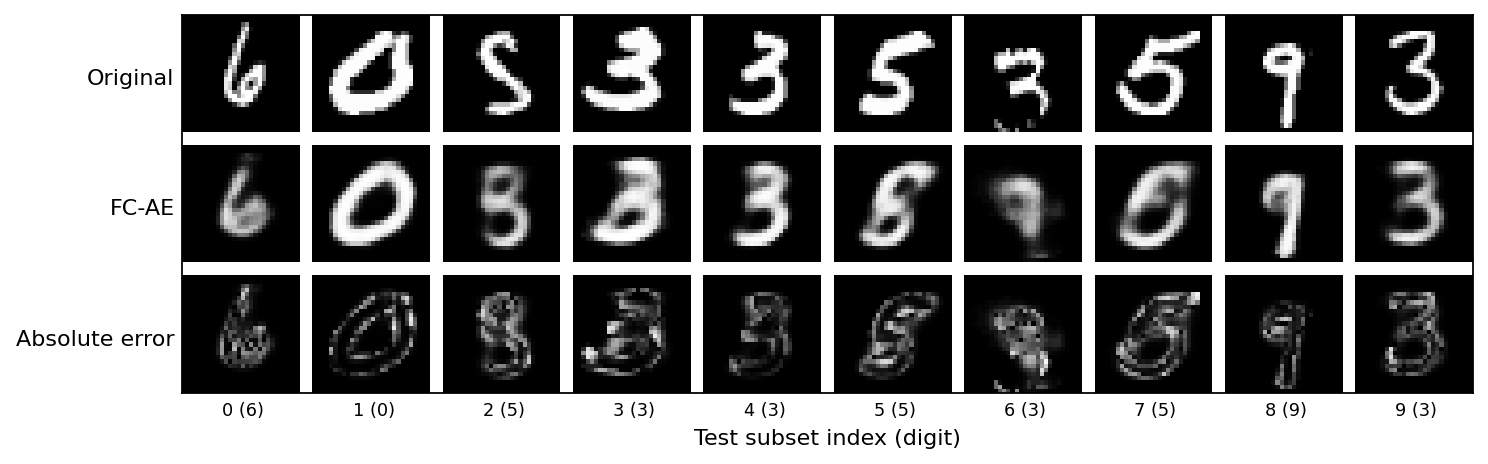

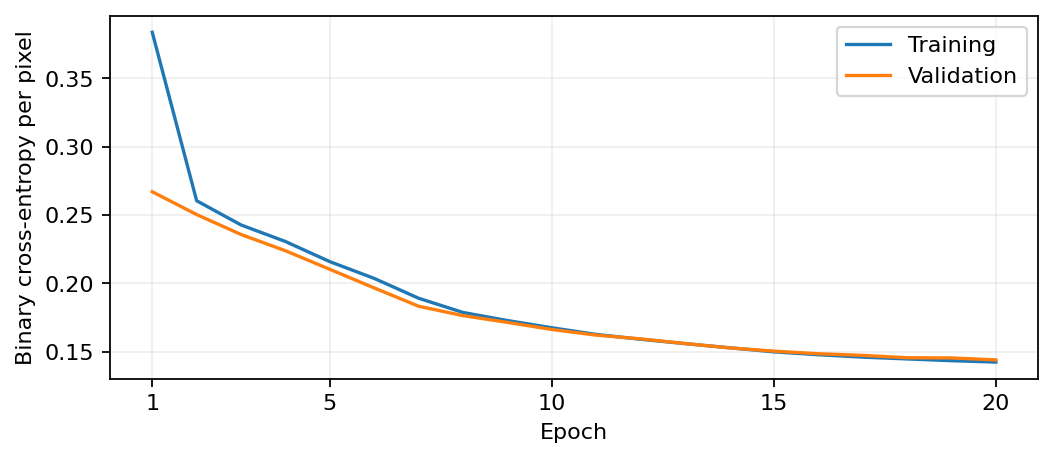

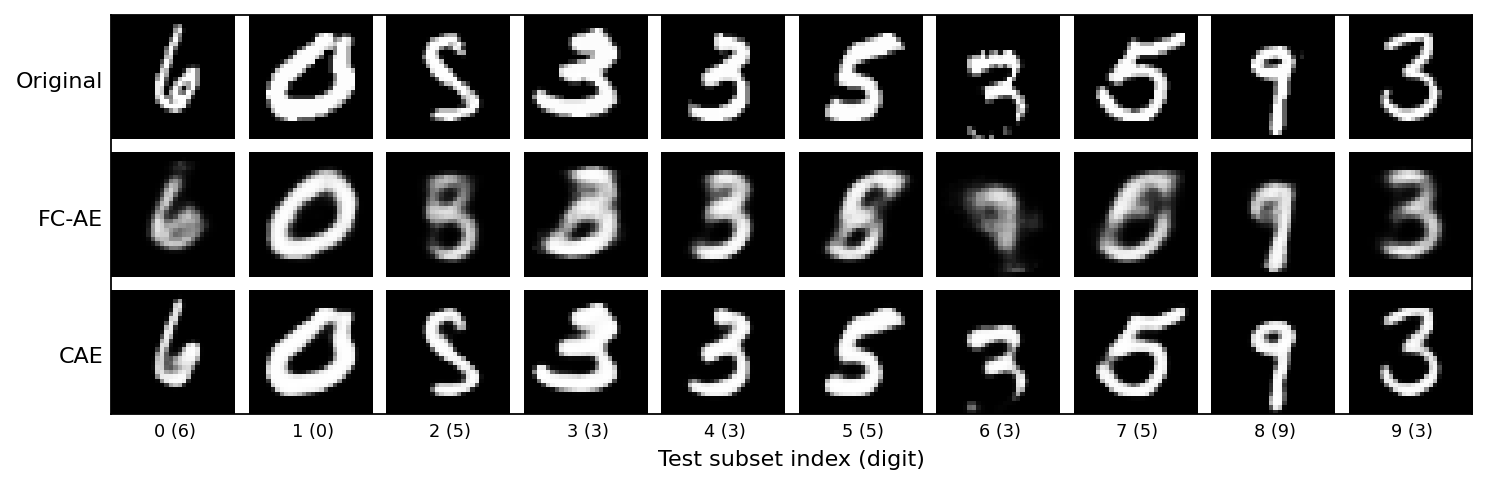

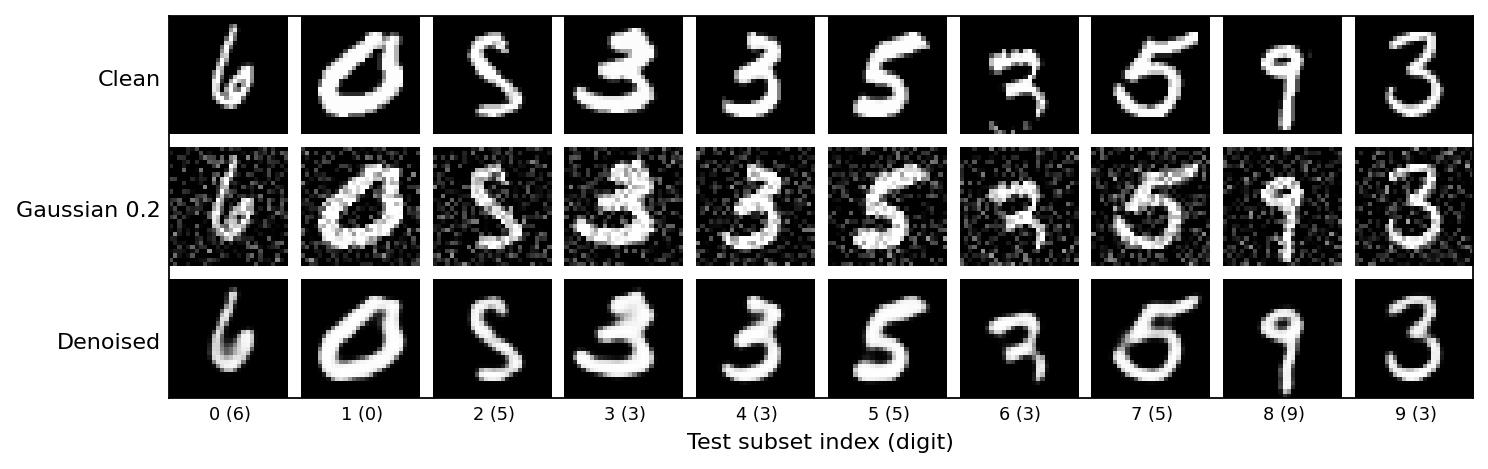

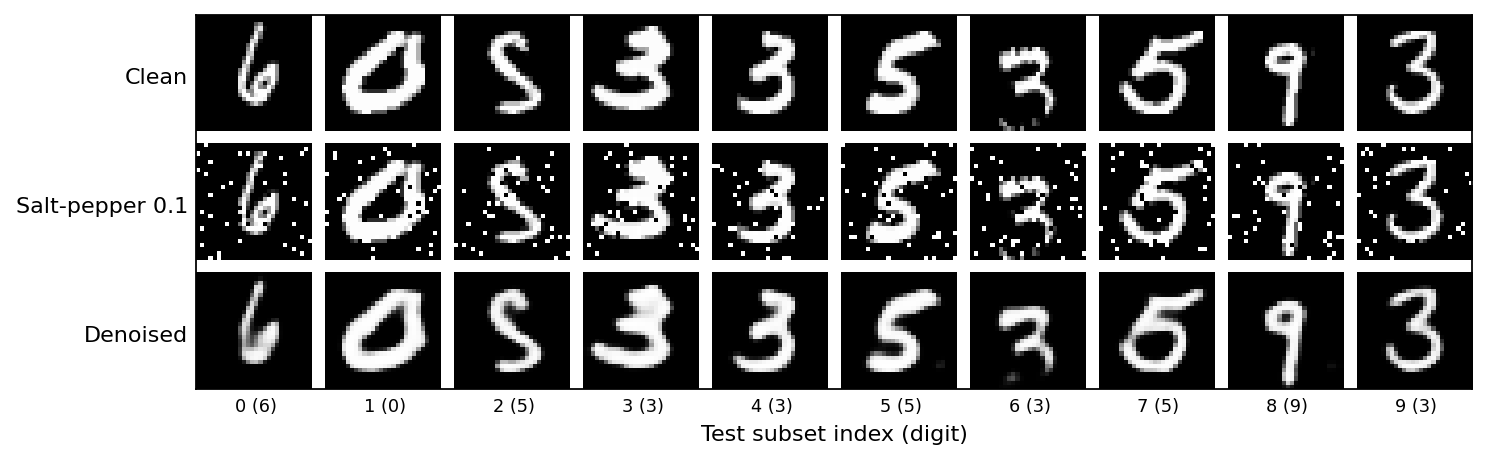

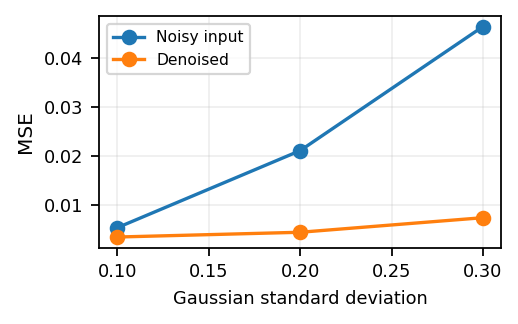

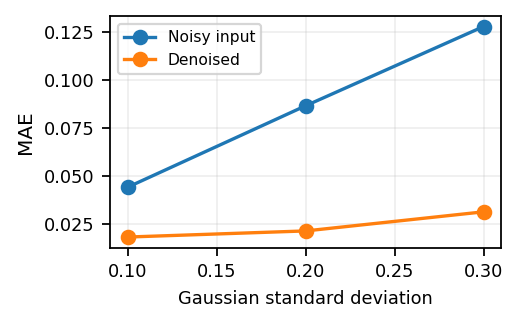

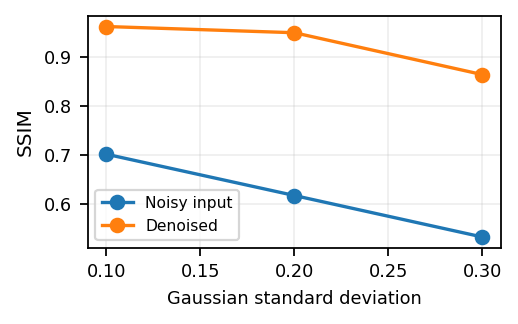

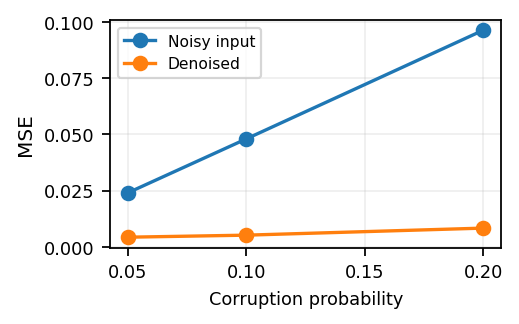

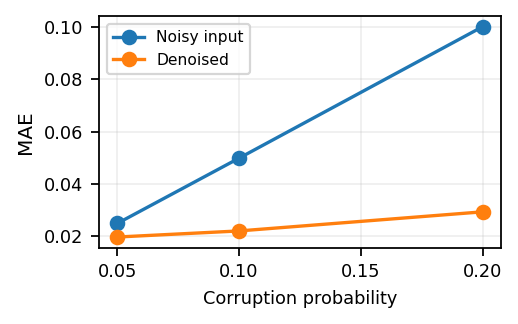

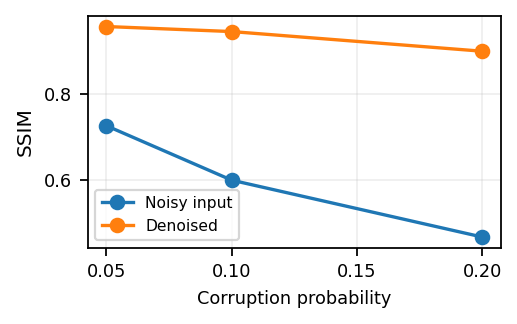

In [11]:
grd([xts, prs["FC_16"], (xts - prs["FC_16"]).abs()],
    ["Original", "FC-AE", "Absolute error"], "01_basic")
crv("FC_16", "rec", "Binary cross-entropy per pixel", "02_fc_loss")
grd([xts, prs["FC_16"], prs["CAE"]],
    ["Original", "FC-AE", "CAE"], "03_comparison")
grd([xts, noi(xts, "Gaussian", 0.2, 301), prs["DAE_G02"]],
    ["Clean", "Gaussian 0.2", "Denoised"], "04_gaussian")
grd([xts, noi(xts, "Salt-pepper", 0.1, 301), prs["DAE_SP10"]],
    ["Clean", "Salt-pepper 0.1", "Denoised"], "05_salt_pepper")
for typ, tag in [("Gaussian", "gaussian"), ("Salt-pepper", "salt_pepper")]:
    for met in ["MSE", "MAE", "SSIM"]:
        plt.figure(figsize=(3.35, 2.1))
        for lbl in ["Noisy input", "Denoised"]:
            tab = nrs[(nrs["Noise"] == typ) & (nrs["Output"] == lbl)]
            plt.plot(tab["Level"], tab[met], marker="o", label=lbl)
        plt.xlabel("Gaussian standard deviation" if typ == "Gaussian" else "Corruption probability", fontsize=8)
        plt.ylabel(met, fontsize=9)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
        plt.legend(fontsize=7)
        plt.grid(alpha=0.2)
        sav("noise_" + tag + "_" + met)

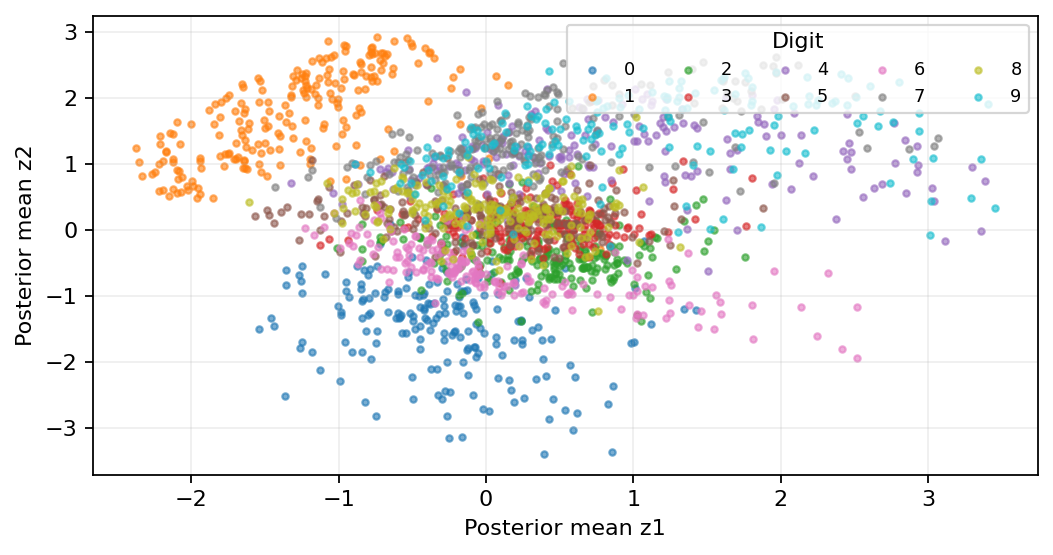

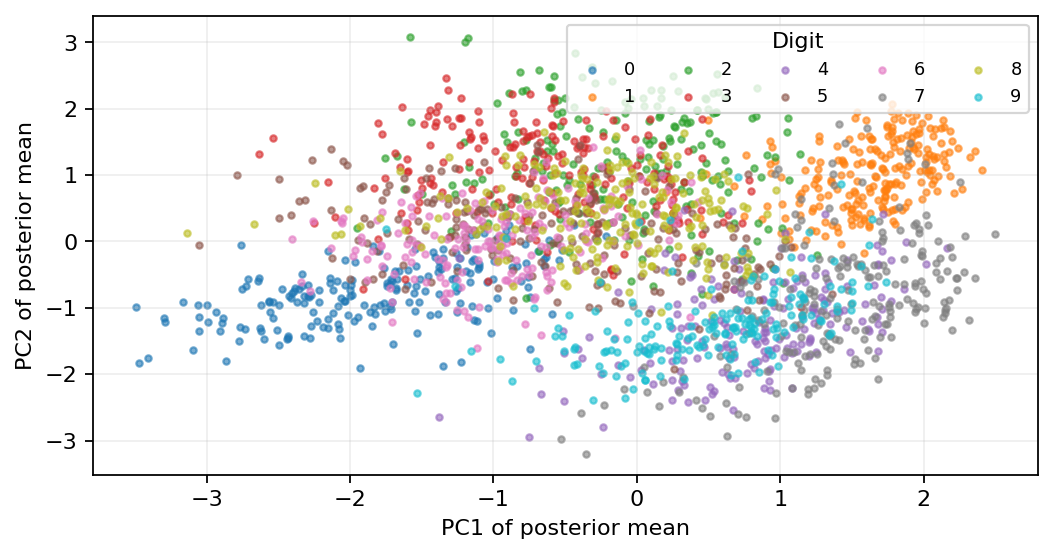

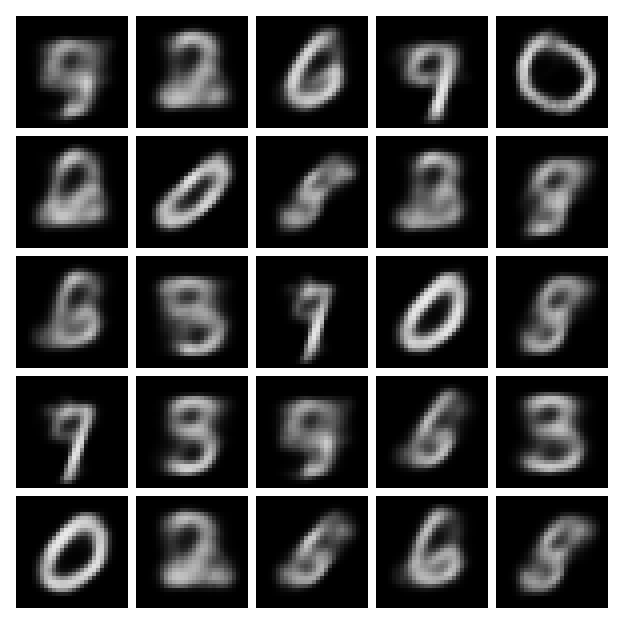

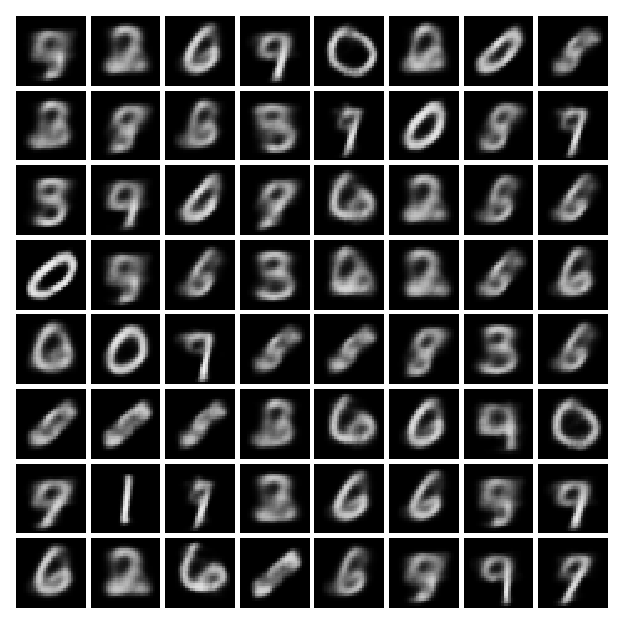

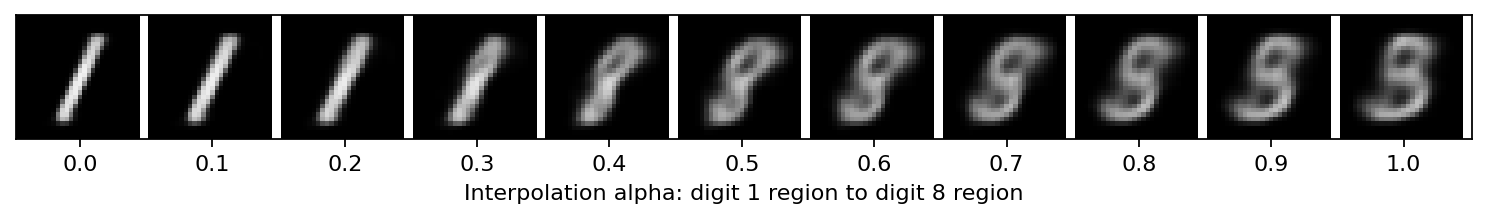

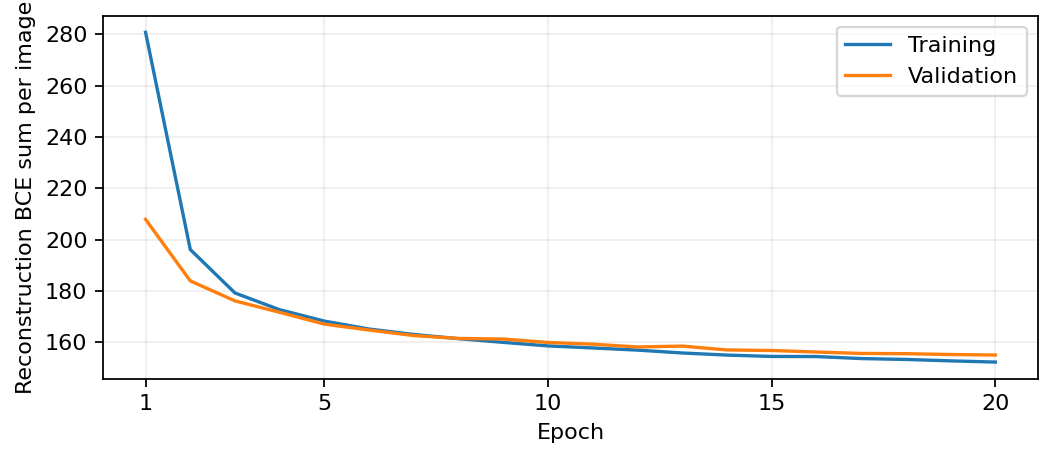

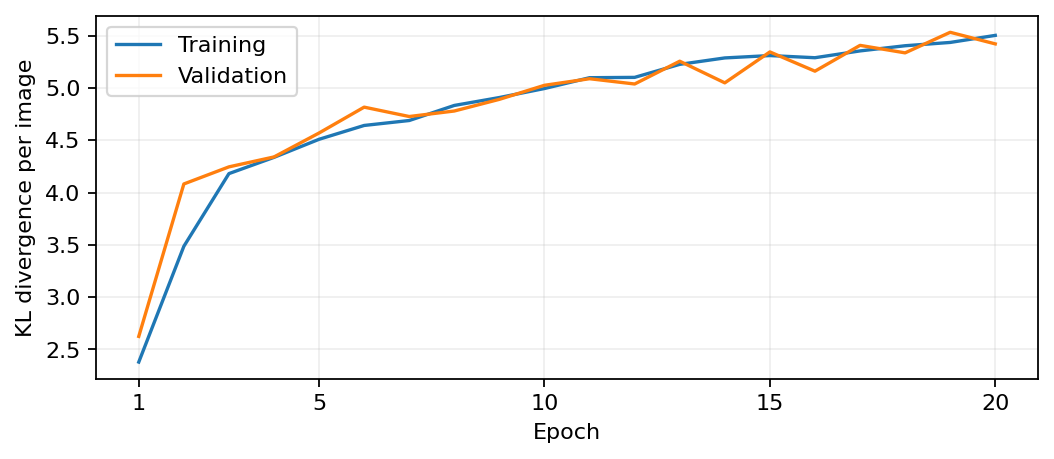

VAE d=2 posterior mean average: [0.12440809 0.38180026]
VAE d=2 posterior mean standard deviation: [0.9361218 1.082317 ]
VAE d=8 PCA variance retained: 0.36713544
Interpolation test indices: [16, 10]
Interpolation endpoints: [[-1.7537267   1.1538157 ]
 [ 0.00909077 -0.05810048]]
Mean adjacent interpolation MSE: 0.0020408262


In [12]:
l02, l08 = lat("VAE_2"), lat("VAE_8")
sca(l02, "06_latent_2", "Posterior mean z1", "Posterior mean z2")
avg = l08.mean(0)
uuu, svd, vvv = npy.linalg.svd(l08 - avg, full_matrices=False)
pcv = (svd[:2] ** 2).sum() / (svd ** 2).sum()
sca((l08 - avg) @ vvv[:2].T, "latent_8_pca", "PC1 of posterior mean", "PC2 of posterior mean")
r25 = gen(mds["VAE_2"], 5, "07_samples_25")
r64 = gen(mds["VAE_2"], 8, "samples_64")
ids = [int(npy.flatnonzero(yts == dig)[0]) for dig in [1, 8]]
alp = npy.linspace(0, 1, 11)
zzz = (1 - alp[:, None]) * l02[ids[0]] + alp[:, None] * l02[ids[1]]
with tch.no_grad():
    itr = tch.sigmoid(mds["VAE_2"]["dec"](tch.tensor(zzz, dtype=tch.float32))).cpu().numpy()[:, 0]
can = npy.concatenate([npy.pad(img, ((0, 0), (0, 2)), constant_values=1)
                       for img in itr], axis=1)
plt.figure(figsize=(9.4, 1.4))
plt.imshow(can, vmin=0, vmax=1, cmap="gray", interpolation="nearest")
plt.xticks([idx * 30 + 14 for idx in range(11)], [f"{val:.1f}" for val in alp])
plt.yticks([])
plt.xlabel("Interpolation alpha: digit 1 region to digit 8 region")
sav("08_interpolation")
crv("VAE_2", "rec", "Reconstruction BCE sum per image", "09_vae_loss")
crv("VAE_2", "kl", "KL divergence per image", "vae_kl_loss")
print("VAE d=2 posterior mean average:", l02.mean(0))
print("VAE d=2 posterior mean standard deviation:", l02.std(0))
print("VAE d=8 PCA variance retained:", pcv)
print("Interpolation test indices:", ids)
print("Interpolation endpoints:", l02[ids])
print("Mean adjacent interpolation MSE:", npy.square(npy.diff(itr, axis=0)).mean())

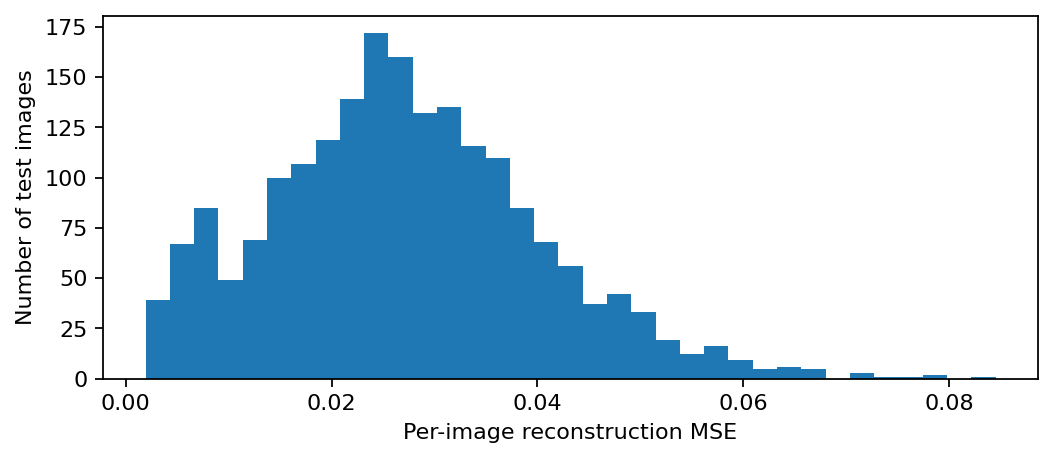

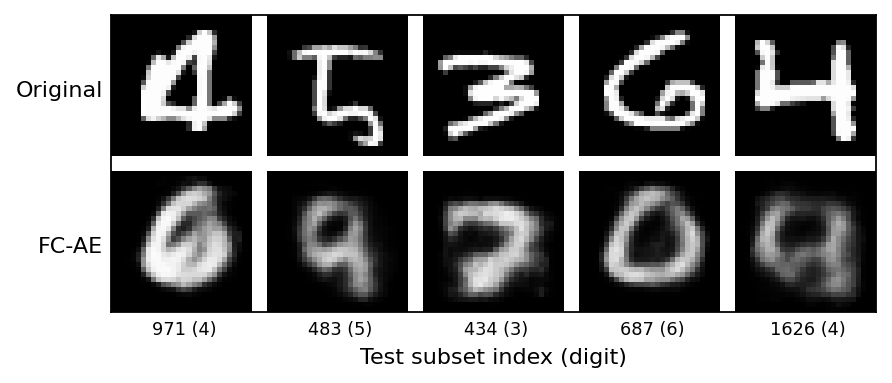

,Test subset index,Official test index,Digit,MSE,SSIM
0,971,5888,4,0.084535,0.427788
1,483,3778,5,0.078507,0.210007
2,434,1601,3,0.077531,0.314963
3,687,8196,6,0.075340,0.399861
4,1626,3841,4,0.073193,0.325368


FC MSE min, P5, P25, median, P75, P95, max: [0.00192794 0.00623016 0.01816751 0.02629569 0.03543223 0.04996309
 0.08453535]


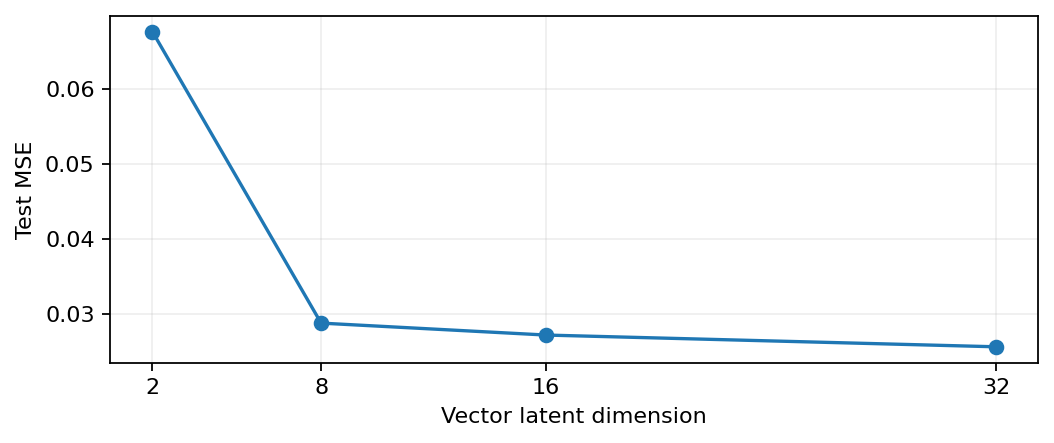

,MSE,MAE,SSIM,Parameters,Time (s)
Model,,,,,
FC_2,0.067606,0.150665,0.177235,210130,5.301177
FC_8,0.028763,0.072645,0.681657,210520,5.661680
FC_16,0.027172,0.069386,0.692002,211040,4.510285
FC_32,0.025608,0.066786,0.706838,212080,4.872762


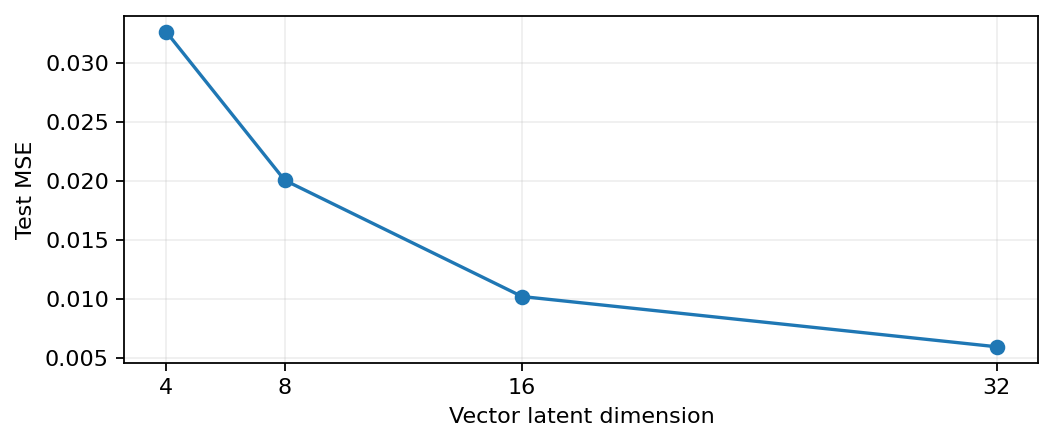

,MSE,MAE,SSIM,Parameters,Time (s)
Model,,,,,
CAE_4,0.032648,0.080543,0.658076,102725,85.699073
CAE_8,0.020067,0.053428,0.789090,127817,87.085942
CAE_16,0.010224,0.033164,0.894051,178001,87.742227
CAE_32,0.005971,0.023702,0.938890,278369,91.397713


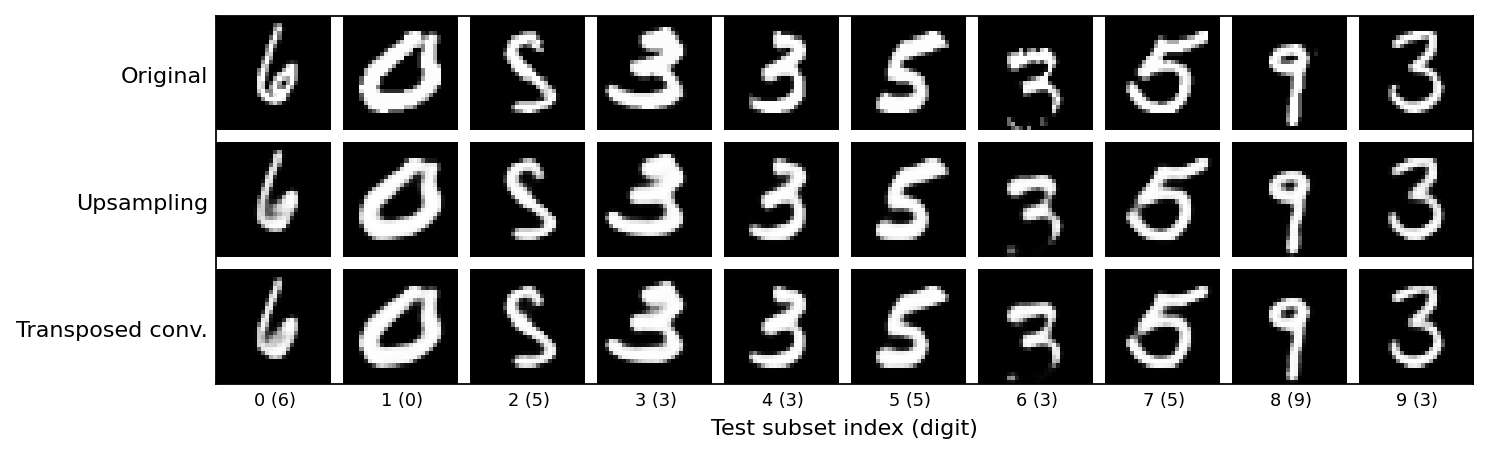

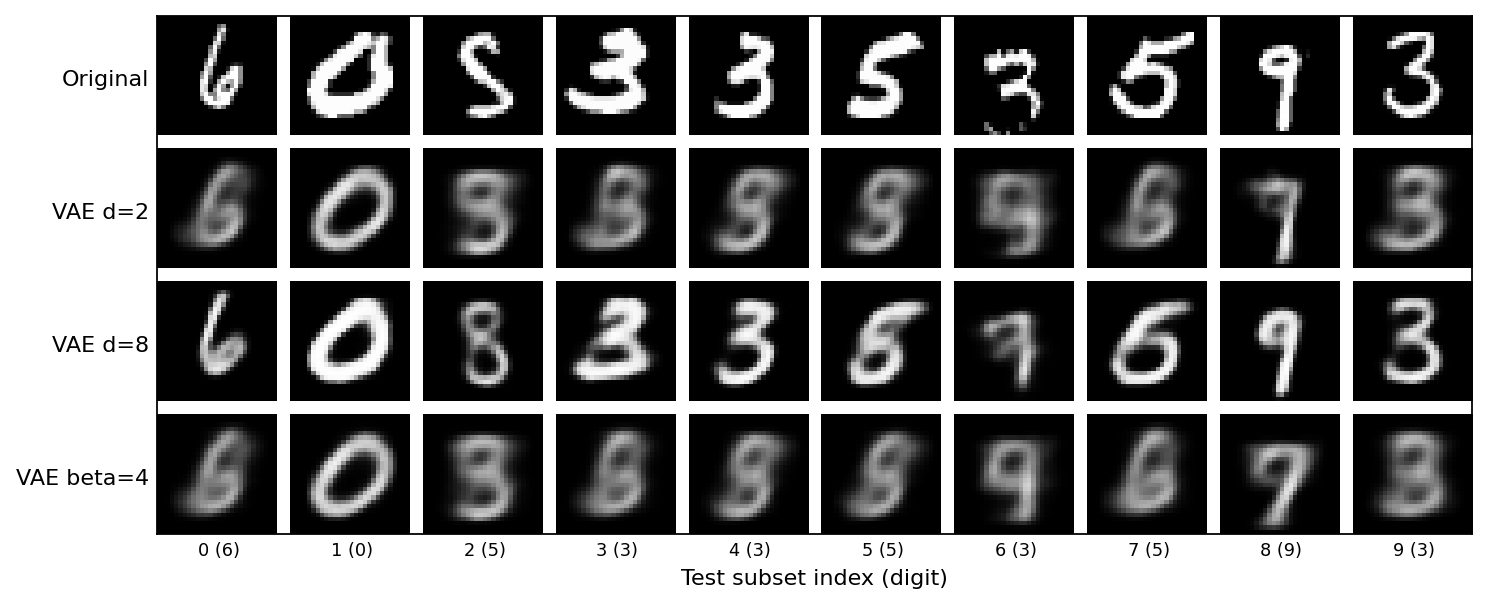

,Latent dimension,Zero-code test images,Inactive coordinates
0,2,2000,2
1,8,0,1
2,16,0,6
3,32,0,7


In [13]:
plt.figure(figsize=(6.7, 3.0))
plt.hist(ers["FC_16"], bins=35)
plt.xlabel("Per-image reconstruction MSE")
plt.ylabel("Number of test images")
sav("10_error_distribution")
hiq = npy.argsort(ers["FC_16"])[-5:][::-1]
grd([xts, prs["FC_16"]], ["Original", "FC-AE"], "high_error", ids=hiq)
her = pds.DataFrame({"Test subset index": hiq, "Official test index": tix[hiq],
                     "Digit": yts[hiq], "MSE": ers["FC_16"][hiq],
                     "SSIM": sms["FC_16"][hiq]})
her.to_csv(out / "high_error_samples.csv", index=False)
dsp(her.round(6))
qnt = npy.quantile(ers["FC_16"], [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1])
print("FC MSE min, P5, P25, median, P75, P95, max:", qnt)
for fam, dim in [("FC", [2, 8, 16, 32]), ("CAE", [4, 8, 16, 32])]:
    tab = res.loc[[f"{fam}_{val}" for val in dim]]
    plt.figure(figsize=(6.7, 2.9))
    plt.plot(dim, tab["MSE"], marker="o")
    plt.xlabel("Vector latent dimension")
    plt.ylabel("Test MSE")
    plt.xticks(dim)
    plt.grid(alpha=0.2)
    sav("latent_dimension_" + fam)
    dsp(tab[["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]].round(6))
grd([xts, prs["CAE"], prs["CAE_transpose"]],
    ["Original", "Upsampling", "Transposed conv."], "decoder_comparison")
grd([xts, prs["VAE_2"], prs["VAE_8"], prs["VAE_beta4"]],
    ["Original", "VAE d=2", "VAE d=8", "VAE beta=4"], "vae_comparison")
zero_rows = []
for dimension in [2, 8, 16, 32]:
    code = lat(f"FC_{dimension}")
    zero_rows.append({"Latent dimension": dimension,
                      "Zero-code test images": int(npy.all(code == 0, axis=1).sum()),
                      "Inactive coordinates": int(npy.all(code == 0, axis=0).sum())})
zero_codes = pds.DataFrame(zero_rows)
zero_codes.to_csv(out / "latent_activity.csv", index=False)
dsp(zero_codes)


In [14]:
man = ["FC_16", "CAE", "DAE_G02", "VAE_2"]
con = res.loc[man, ["Input", "Level", "MSE", "MAE", "SSIM", "Parameters", "Time (s)"]]
dsp(con.round(6))
dsp(res.loc[["VAE_2", "VAE_8", "VAE_beta4"],
            ["Reconstruction loss", "KL loss", "Total loss", "MSE", "MAE", "SSIM"]].round(6))
epo = hst["FC_16"][["epoch", "train_rec", "val_rec"]].copy()
epo.columns = ["Epoch", "FC train BCE", "FC validation BCE"]
epo["VAE train reconstruction"] = hst["VAE_2"]["train_rec"]
epo["VAE validation reconstruction"] = hst["VAE_2"]["val_rec"]
epo["VAE train KL"] = hst["VAE_2"]["train_kl"]
epo["VAE validation KL"] = hst["VAE_2"]["val_kl"]
epo.to_csv(out / "epoch_values.csv", index=False)
dsp(epo.round(6))
assert len(res) == 16
assert all(len(tab) == 20 for tab in hst.values())
assert npy.isfinite(res[["MSE", "MAE", "SSIM", "Parameters", "Time (s)"]].to_numpy()).all()
assert all(tuple(arr.shape) == (2000, 1, 28, 28) for arr in prs.values())
assert len(nrs) == 12 and len(trs) == 6
print("Completed:", len(res), "trained models; all expected result tables are populated.")
summary = {"architecture": arc, "fc_error_quantiles": qnt.tolist(),
           "vae_mean_average": l02.mean(0).tolist(),
           "vae_mean_standard_deviation": l02.std(0).tolist(),
           "vae_8_pca_variance": float(pcv),
           "interpolation_indices": ids,
           "interpolation_endpoints": l02[ids].tolist(),
           "adjacent_interpolation_mse": float(npy.square(npy.diff(itr, axis=0)).mean()),
           "model_count": len(res), "epochs_per_model": cfg["epochs"]}
(out / "analysis_summary.json").write_text(jsn.dumps(summary, indent=2))
per_image = pds.DataFrame({"Subset index": npy.arange(len(xts)),
                          "Official test index": tix, "Digit": yts})
for model_name in res.index:
    per_image[model_name + " MSE"] = ers[model_name]
    per_image[model_name + " SSIM"] = sms[model_name]
per_image.to_csv(out / "per_image_metrics.csv", index=False)
npy.savez_compressed(out / "vae_analysis.npz", latent_2=l02, latent_8=l08,
                     generated_25=r25, generated_64=r64, interpolation=itr,
                     alpha=alp, labels=yts)


,Input,Level,MSE,MAE,SSIM,Parameters,Time (s)
Model,,,,,,,
FC_16,Clean,0.0,0.027172,0.069386,0.692002,211040,4.510285
CAE,Clean,0.0,0.002742,0.015532,0.974080,74497,76.856964
DAE_G02,Gaussian,0.2,0.004493,0.021158,0.948878,74497,75.239862
VAE_2,Clean,0.0,0.045632,0.106545,0.492553,139461,104.951207


,Reconstruction loss,KL loss,Total loss,MSE,MAE,SSIM
Model,,,,,,
VAE_2,155.082552,5.419465,160.502017,0.045632,0.106545,0.492553
VAE_8,99.202801,15.919328,115.122128,0.019473,0.053841,0.786753
VAE_beta4,160.805074,3.433870,174.540554,0.046787,0.111755,0.464868


,Epoch,FC train BCE,FC validation BCE,VAE train reconstruction,VAE validation reconstruction,VAE train KL,VAE validation KL
0,1,0.383683,0.267022,280.733671,207.879523,2.377992,2.623539
1,2,0.260430,0.250345,196.123581,183.910437,3.485422,4.081835
2,3,0.242723,0.235748,179.189367,176.119411,4.180863,4.245432
3,4,0.230611,0.223870,172.673677,171.658003,4.336346,4.340399
4,5,0.215878,0.210273,168.242150,167.061602,4.509271,4.569596
5,6,0.203615,0.196650,165.147020,164.761156,4.641628,4.816841
6,7,0.189107,0.183259,163.036067,162.598648,4.688947,4.727082
7,8,0.178692,0.176393,161.402821,161.492078,4.833148,4.779849
8,9,0.172797,0.171446,159.958629,161.260051,4.908750,4.891476
9,10,0.167517,0.166253,158.585968,159.926098,4.995004,5.025813


Completed: 16 trained models; all expected result tables are populated.
